      CRIM    ZN  INDUS  CHAS    NOX     RM   AGE     DIS  RAD  TAX  PTRATIO  \
0  0.00632  18.0   2.31     0  0.538  6.575  65.2  4.0900    1  296     15.3   
1  0.02731   0.0   7.07     0  0.469  6.421  78.9  4.9671    2  242     17.8   
2  0.02729   0.0   7.07     0  0.469  7.185  61.1  4.9671    2  242     17.8   
3  0.03237   0.0   2.18     0  0.458  6.998  45.8  6.0622    3  222     18.7   
4  0.06905   0.0   2.18     0  0.458  7.147  54.2  6.0622    3  222     18.7   

        B  LSTAT  MEDV  BIAS_COL  
0  396.90   4.98  24.0         1  
1  396.90   9.14  21.6         1  
2  392.83   4.03  34.7         1  
3  394.63   2.94  33.4         1  
4  396.90   5.33  36.2         1  

Missing Values:
 CRIM        0
ZN          0
INDUS       0
CHAS        0
NOX         0
RM          0
AGE         0
DIS         0
RAD         0
TAX         0
PTRATIO     0
B           0
LSTAT       0
MEDV        0
BIAS_COL    0
dtype: int64

Statistics:
              CRIM          ZN       INDUS        CHAS 

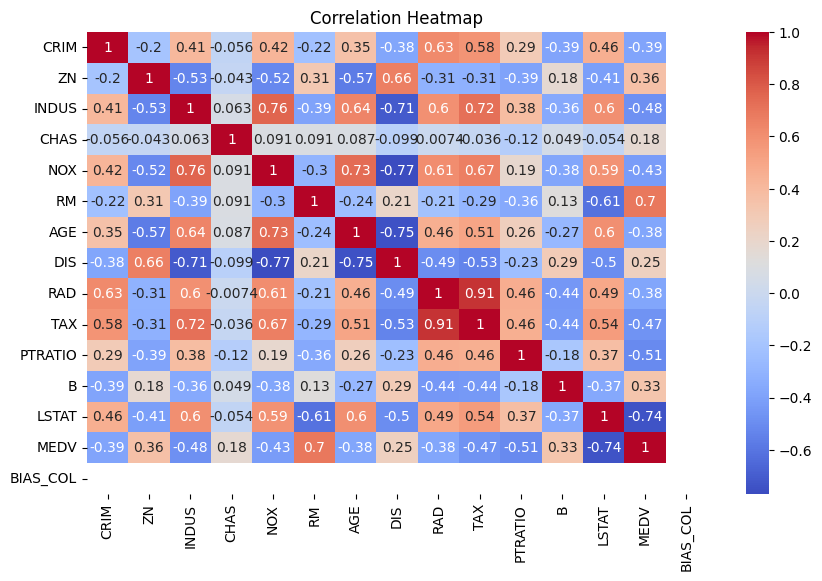


Mean Squared Error: 26.782523432699975
R2 Score: 0.6347860115964863

Feature Importance:
          Coefficient
RM          4.776817
LSTAT      -0.593496
PTRATIO    -0.948690
INDUS       0.065783
NOX        -8.650123
AGE         0.032273


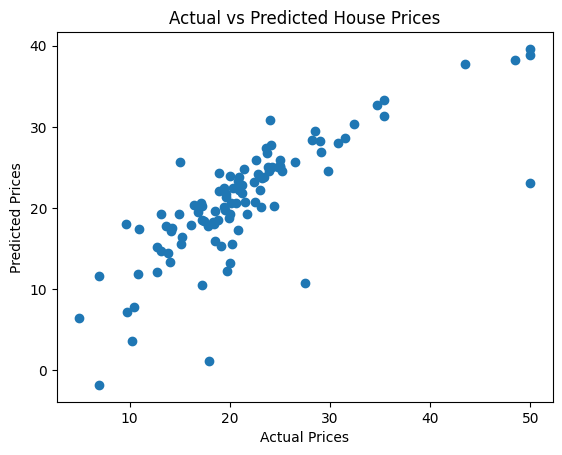

In [1]:
# Import Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

# 1. Load Data
df = pd.read_csv("boston.csv")   # Change filename if needed

# Display first rows
print(df.head())

# 2. Explore Data
print("\nMissing Values:\n", df.isnull().sum())
print("\nStatistics:\n", df.describe())

# Correlation Heatmap
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

# 3. Prepare Data
features = ['RM', 'LSTAT', 'PTRATIO', 'INDUS', 'NOX', 'AGE']
X = df[features]
y = df['MEDV']

# Train-Test Split (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 4. Build Model
model = LinearRegression()
model.fit(X_train, y_train)

# 5. Evaluate Model
y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("\nMean Squared Error:", mse)
print("R2 Score:", r2)

# 6. Interpretation (Coefficients)
coeff_df = pd.DataFrame(model.coef_, features, columns=['Coefficient'])
print("\nFeature Importance:\n", coeff_df)

# Plot Actual vs Predicted
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted House Prices")
plt.show()